Plot successfully saved to Supplementary_Figure_S1a.pdf.


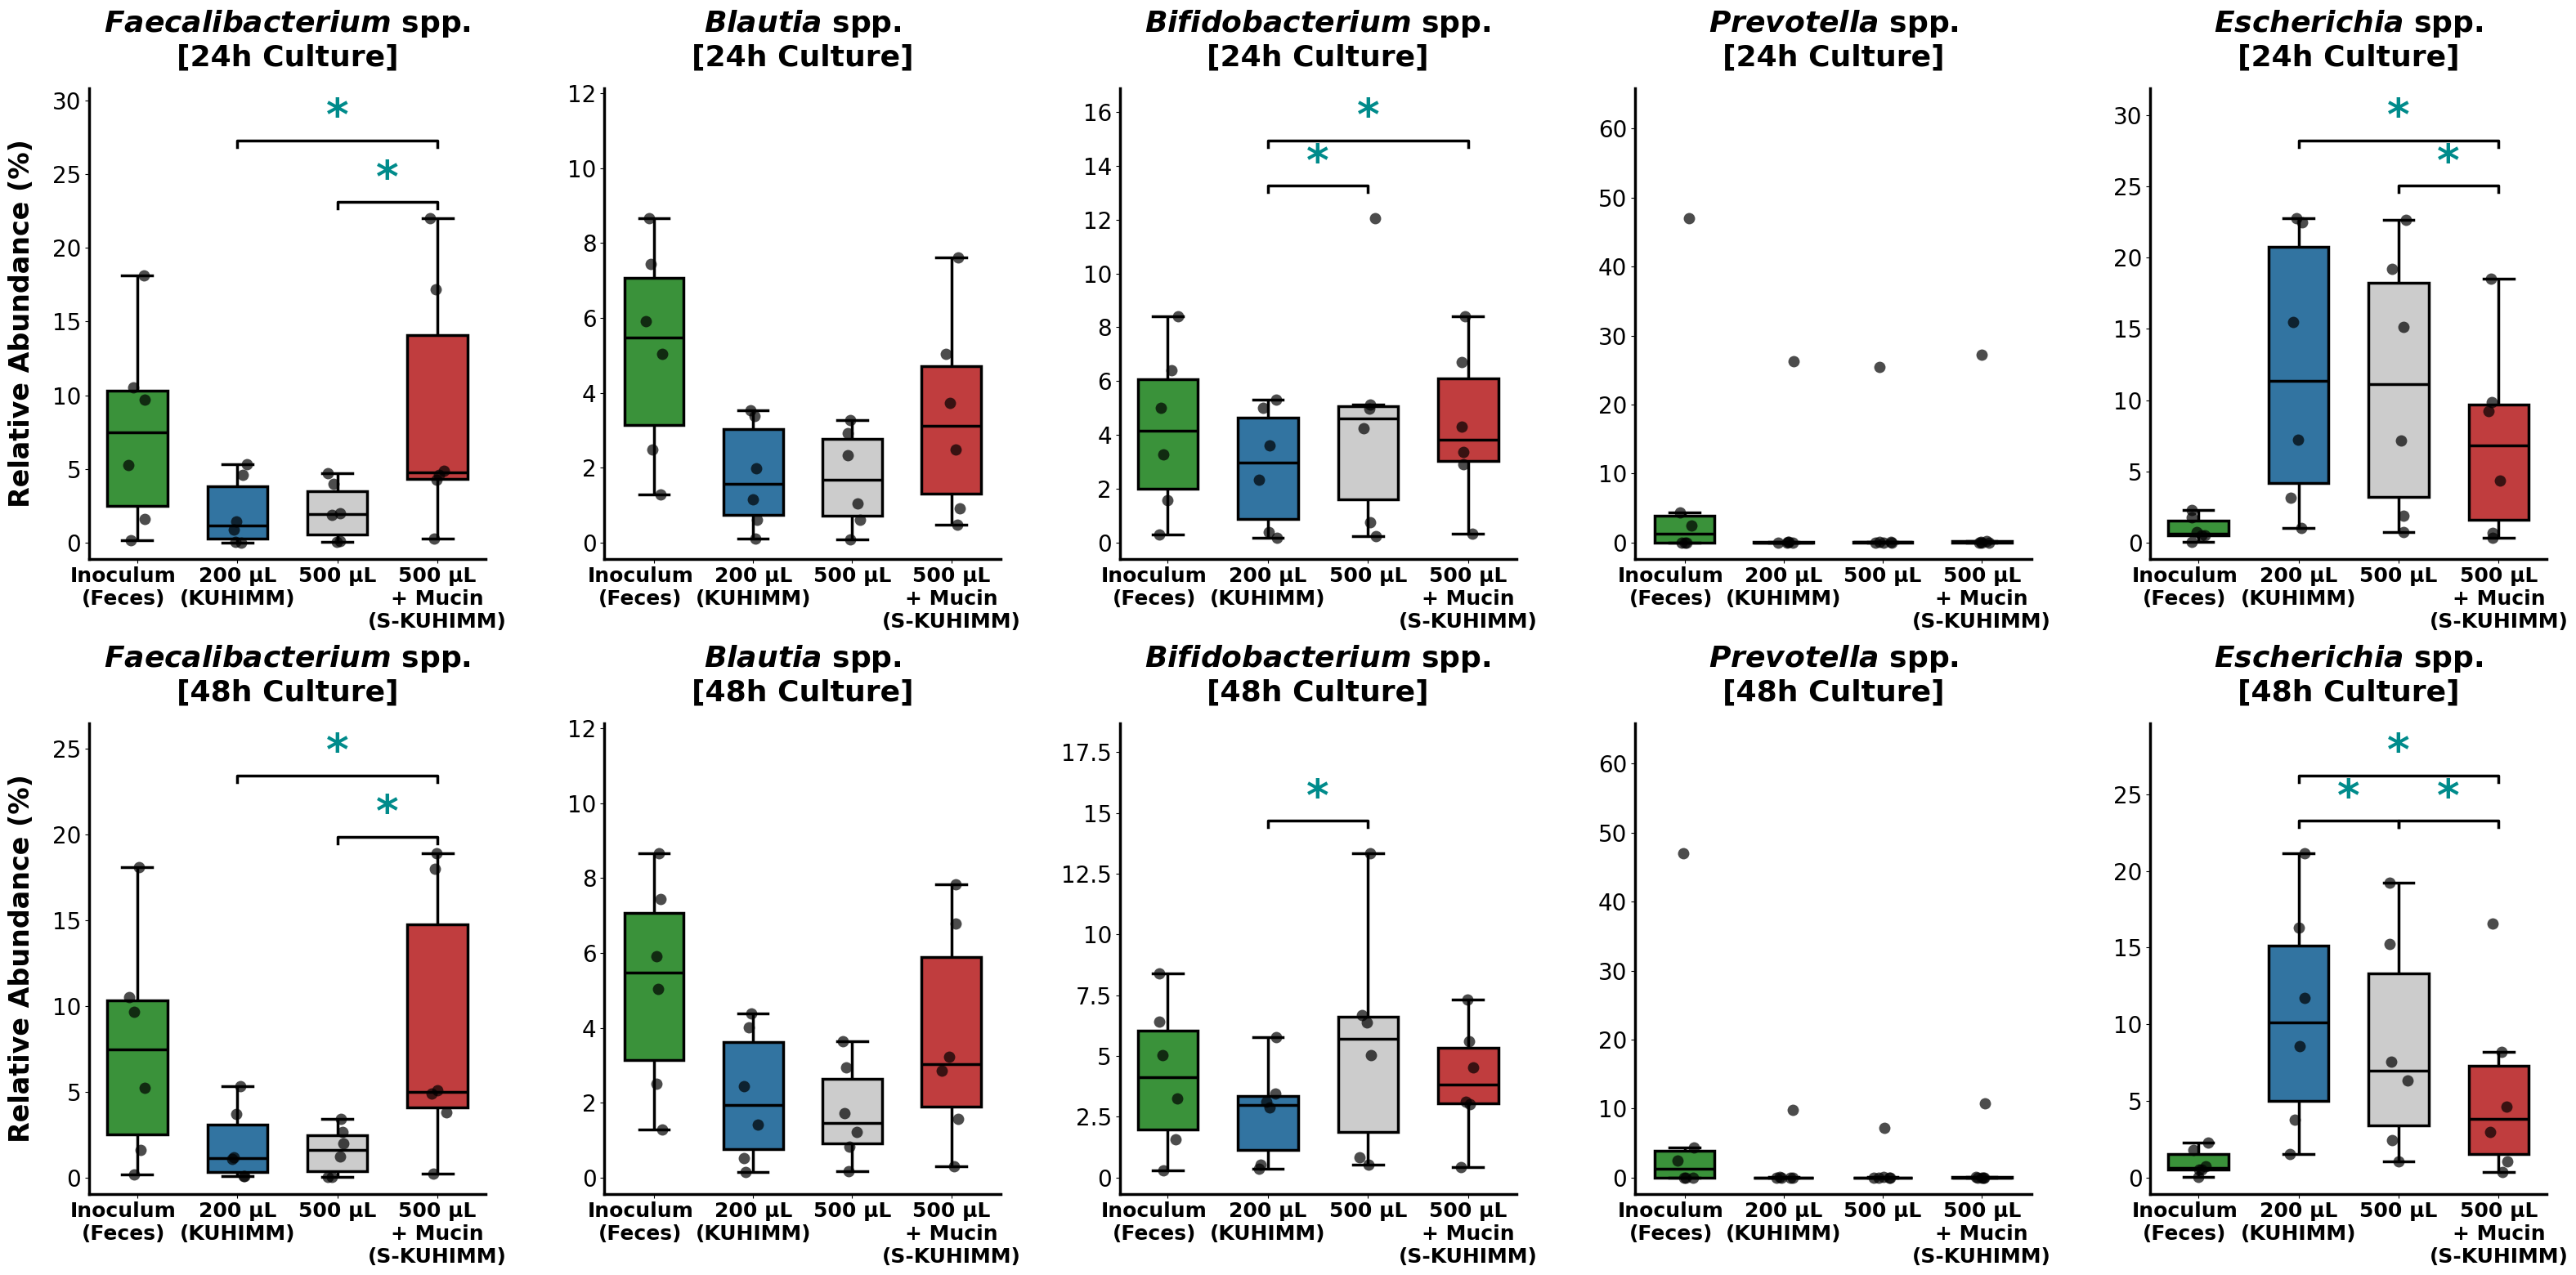

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
import matplotlib.transforms as mtransforms
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# =============================================================================
# Global Plotting Configuration (Strict Nature Standards)
# =============================================================================
plt.rcParams.update({
    'font.size': 20,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'sans-serif'],
    'pdf.fonttype': 42,
    'axes.linewidth': 2.5,
    'mathtext.default': 'regular'
})

# Universal Settings for Significance Markers
STAR_COLOR = '#008B8B'  # Dark Turquoise
STAR_SIZE = 38

def annotate_p(ax, x1, x2, y, h, p_val):
    """Adds a strict, professional statistical bracket with a turquoise asterisk."""
    if p_val < 0.05:
        ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=2.5, c='k')
        ax.text((x1+x2)*0.5, y+h + h*0.2, '*', ha='center', va='bottom',
                color=STAR_COLOR, fontsize=STAR_SIZE, fontweight='bold')

# =============================================================================
# 1. Load Data & Filter for 24h and 48h Time Points
# =============================================================================
df = pd.read_csv('(1d)_500muc_16S_Genus_level.csv')
bac_cols = [c for c in df.columns if c.startswith('d__Bacteria')]

def get_group_time(c):
    """Classify samples into respective groups, filtering for 24h and 48h."""
    if 'FEC' in c:
        return 'Inoculum', '0h'

    time = None
    if '24h' in c: time = '24h'
    elif '48h' in c: time = '48h'
    elif '72h' in c: time = '72h'

    # Exclude 72h (handled in Fig 1e)
    if time not in ['24h', '48h']:
        return None, None

    is_mucin = any(m in c for m in ['MUC', '0.8gMUC', '08MUC'])

    if '200' in c:
        return 'KUHIMM (200µL)', time
    elif '500' in c:
        return 'S-KUHIMM (500µL+Mucin)' if is_mucin else 'KUHIMM (500µL)', time
    return None, None

df['Group'], df['Time'] = zip(*df['Condition'].apply(get_group_time))
df['Donor'] = df['Condition'].str.extract(r'^(HS-[^-]+|[^0-9-]+)')
df['Total_Bac'] = df[bac_cols].sum(axis=1)

# =============================================================================
# 2. Extract Relative Abundances of Target Guilds
# =============================================================================
df['Faecalibacterium'] = df[[c for c in bac_cols if 'Faecalibacterium' in c]].sum(axis=1) / df['Total_Bac'] * 100
df['Blautia'] = df[[c for c in bac_cols if 'Blautia' in c]].sum(axis=1) / df['Total_Bac'] * 100
df['Bifidobacterium'] = df[[c for c in bac_cols if 'Bifidobacterium' in c]].sum(axis=1) / df['Total_Bac'] * 100
df['Prevotella'] = df[[c for c in bac_cols if 'f__Prevotellaceae' in c]].sum(axis=1) / df['Total_Bac'] * 100
df['Escherichia'] = df[[c for c in bac_cols if 'Escherichia' in c]].sum(axis=1) / df['Total_Bac'] * 100

plot_df = df.dropna(subset=['Group']).copy()
agg_cols = ['Faecalibacterium', 'Blautia', 'Bifidobacterium', 'Prevotella', 'Escherichia']
plot_df = plot_df.groupby(['Donor', 'Group', 'Time'])[agg_cols].mean().reset_index()

# =============================================================================
# 3. Formatting & Plotting Setup
# =============================================================================
x_order = ['Inoculum', 'KUHIMM (200µL)', 'KUHIMM (500µL)', 'S-KUHIMM (500µL+Mucin)']
palette = {
    'Inoculum': '#2ca02c',
    'KUHIMM (200µL)': '#1f77b4',
    'KUHIMM (500µL)': '#CCCCCC',
    'S-KUHIMM (500µL+Mucin)': '#d62728'
}

# 2x5 grid (Row 1 = 24h, Row 2 = 48h)
fig, axes = plt.subplots(2, 5, figsize=(32, 16))

genera_cols = ['Faecalibacterium', 'Blautia', 'Bifidobacterium', 'Prevotella', 'Escherichia']
x_labels = ['Inoculum\n(Feces)', '200 µL\n(KUHIMM)', '500 µL', '500 µL\n+ Mucin\n(S-KUHIMM)']
titles = [
    r'$\mathit{Faecalibacterium}$ $\mathbf{spp.}$',
    r'$\mathit{Blautia}$ $\mathbf{spp.}$',
    r'$\mathit{Bifidobacterium}$ $\mathbf{spp.}$',
    r'$\mathit{Prevotella}$ $\mathbf{spp.}$',
    r'$\mathit{Escherichia}$ $\mathbf{spp.}$'
]

# Logic for slightly shifting the "Inoculum" label to the left
dx_points = -12 / 72.0
offset = mtransforms.ScaledTranslation(dx_points, 0, fig.dpi_scale_trans)

# =============================================================================
# 4. Rendering Subplots (24h & 48h)
# =============================================================================
for row_idx, target_time in enumerate(['24h', '48h']):
    # Subset data for the specific time point (+ Inoculum baseline)
    sub_df = plot_df[(plot_df['Time'] == target_time) | (plot_df['Group'] == 'Inoculum')]

    for i, g in enumerate(genera_cols):
        ax = axes[row_idx, i]

        # Boxplots
        sns.boxplot(x='Group', y=g, data=sub_df, order=x_order, palette=palette,
                    width=0.6, ax=ax, showfliers=False, linewidth=2.5, boxprops=dict(alpha=1.0))

        for patch in ax.patches: patch.set_edgecolor('black')
        for line in ax.lines: line.set_color('black')

        # Stripplots
        sns.stripplot(x='Group', y=g, data=sub_df, order=x_order, color='black',
                      alpha=0.7, size=10, jitter=True, ax=ax)

        # Titles & Labels
        time_tag = "[24h Culture]" if row_idx == 0 else "[48h Culture]"
        ax.set_title(titles[i] + f"\n{time_tag}", fontsize=26, fontweight='bold', pad=20)
        ax.set_xlabel("")

        if i == 0:
            ax.set_ylabel("Relative Abundance (%)", fontsize=24, fontweight='bold', labelpad=15)
        else:
            ax.set_ylabel("")

        ax.set_xticks(range(4))
        ax.set_xticklabels(x_labels, rotation=0, ha='center', fontsize=18, fontweight='bold')

        # Apply the left-shift offset to "Inoculum"
        for label in ax.get_xticklabels():
            if "Inoculum" in label.get_text():
                label.set_transform(label.get_transform() + offset)

        # =====================================================================
        # 5. Statistical Testing (Tiered Brackets)
        # =====================================================================
        k_200 = sub_df[sub_df['Group'] == 'KUHIMM (200µL)'].sort_values('Donor')[g].values
        k_500 = sub_df[sub_df['Group'] == 'KUHIMM (500µL)'].sort_values('Donor')[g].values
        s_muc = sub_df[sub_df['Group'] == 'S-KUHIMM (500µL+Mucin)'].sort_values('Donor')[g].values

        data_max = sub_df[g].max()
        if data_max < 1: data_max = 1.0

        y_tier1 = data_max + data_max*0.08
        y_tier2 = data_max + data_max*0.22
        bracket_height = data_max*0.02

        # Optional logic: Lower the 500µL vs S-KUHIMM bracket specifically for Faecalibacterium/Blautia
        custom_tier1_500vsMuc = y_tier1
        if i == 0 or i == 1:
            custom_tier1_500vsMuc = data_max + data_max*0.03

        if len(k_200) == len(k_500) and len(k_500) == len(s_muc) and len(k_200) > 0:
            _, p_200_500 = wilcoxon(k_200, k_500)
            _, p_500_muc = wilcoxon(k_500, s_muc)
            _, p_200_muc = wilcoxon(k_200, s_muc)

            if p_200_500 < 0.05:
                annotate_p(ax, 1, 2, y_tier1, bracket_height, p_200_500)
            if p_500_muc < 0.05:
                annotate_p(ax, 2, 3, custom_tier1_500vsMuc, bracket_height, p_500_muc)
            if p_200_muc < 0.05:
                annotate_p(ax, 1, 3, y_tier2, bracket_height, p_200_muc)

        # Dynamic Limits & Normal-Weight Y-ticks
        ax.set_ylim(bottom=-data_max*0.05, top=data_max + data_max*0.40)
        yticks = ax.get_yticks()
        valid_yticks = [tick for tick in yticks if tick >= 0 and tick <= (data_max + data_max*0.40)]
        ax.set_yticks(valid_yticks)
        labels_y = ax.set_yticklabels([f"{tick:g}" for tick in valid_yticks], fontsize=20)
        for label in labels_y:
            label.set_fontweight('normal')

sns.despine()
plt.tight_layout()
# Increase vertical space (hspace) so 24h brackets don't collide with 48h titles
plt.subplots_adjust(wspace=0.3, hspace=0.35)

# Export High-Resolution PDF
output_file = "Supplementary_Figure_S1a.pdf"
plt.savefig(output_file, dpi=600, transparent=True, bbox_inches='tight', pad_inches=0.2)
print(f"Plot successfully saved to {output_file}.")